# Annotator-level raw dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_parquet("hf://datasets/google-research-datasets/go_emotions/raw/train-00000-of-00001.parquet")

/opt/anaconda3/envs/ml/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape of dataset: (211225, 37)

Columns: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [4]:
df.isnull().sum()

text                    0
id                      0
author                  0
subreddit               0
link_id                 0
parent_id               0
created_utc             0
rater_id                0
example_very_unclear    0
admiration              0
amusement               0
anger                   0
annoyance               0
approval                0
caring                  0
confusion               0
curiosity               0
desire                  0
disappointment          0
disapproval             0
disgust                 0
embarrassment           0
excitement              0
fear                    0
gratitude               0
grief                   0
joy                     0
love                    0
nervousness             0
optimism                0
pride                   0
realization             0
relief                  0
remorse                 0
sadness                 0
surprise                0
neutral                 0
dtype: int64

## Basic EDA

### Text Length analysis

Most comments are short (median is approximately 13 words), indicating that emotional signals are often expressed concisely. This may limit the amount of contextual information available for classification.

In [5]:
df["char_len"] = df["text"].astype(str).str.len()
df["word_len"] = df["text"].astype(str).str.split().str.len()

df[["char_len", "word_len"]].describe()

,char_len,word_len
count,211225.000000,211225.000000
mean,69.299572,12.997188
std,36.536746,6.676105
min,2.000000,1.000000
25%,39.000000,7.000000
50%,67.000000,13.000000
75%,97.000000,18.000000
max,703.000000,33.000000


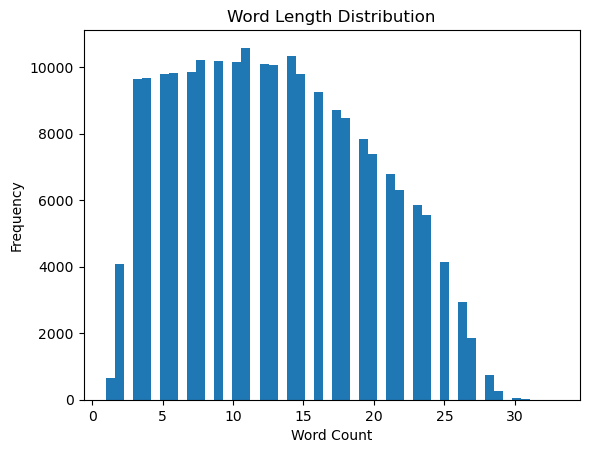

In [6]:
plt.hist(df["word_len"], bins=50)
plt.title("Word Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### Checking Duplicates

These repetitions are due to multiple annotators labeling the same comment, not duplicate data entries.

In [7]:
dup_counts = df['text'].value_counts()
print("\nTexts with multiple annotations:")
print(dup_counts[dup_counts > 1].head())


Texts with multiple annotations:
text
Thank you.           45
Thank you!           35
Happy cake day!      29
Weird flex but ok    25
I like it            22
Name: count, dtype: int64


### Emotions

In [8]:
emotion_cols_27 = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise"
]

# optional (for analysis only)
emotion_cols_28 = emotion_cols_27 + ["neutral"]

### Label Frequency

The distribution is highly imbalanced, with neutral dominating. This suggests that many comments lack strong emotional content, which may affect both clustering and classification performance.

In [9]:
label_counts = df[emotion_cols_28].sum().sort_values(ascending=False)

print(label_counts)

neutral           55298
approval          17620
admiration        17131
annoyance         13618
gratitude         11625
disapproval       11424
curiosity          9692
amusement          9245
realization        8785
optimism           8715
disappointment     8469
love               8191
anger              8084
joy                7983
confusion          7359
sadness            6758
caring             5999
excitement         5629
surprise           5514
disgust            5301
desire             3817
fear               3197
remorse            2525
embarrassment      2476
nervousness        1810
pride              1302
relief             1289
grief               673
dtype: int64


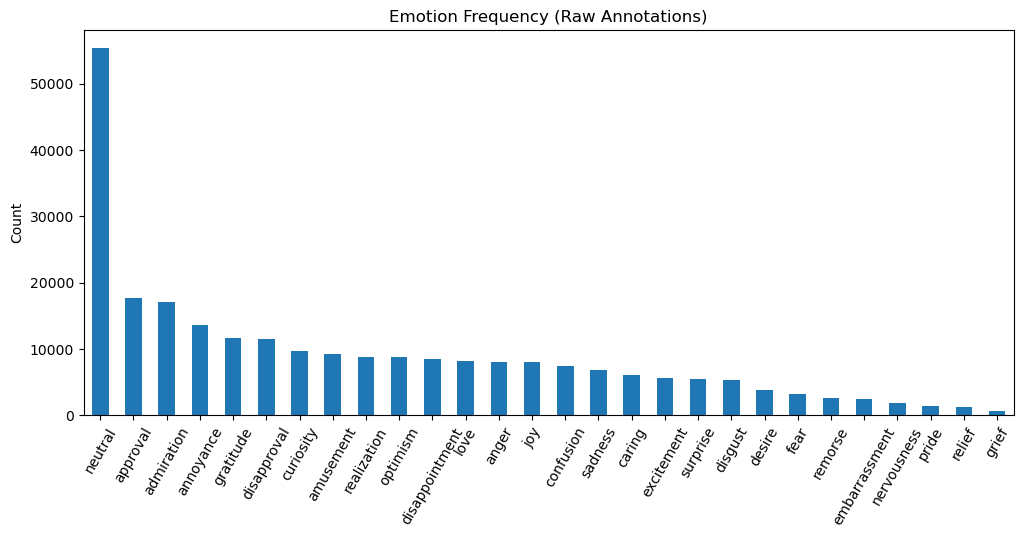

In [10]:
label_counts.plot(kind="bar", figsize=(12,5))
plt.title("Emotion Frequency (Raw Annotations)")
plt.ylabel("Count")
plt.xticks(rotation=60)
plt.show()

### Multi-label per annotation

While most annotations contain a single label, a significant number contain multiple labels, indicating that emotional expression is often complex. This supports the need for entropy-based features.

In [11]:
df["labels_per_annotation"] = df[emotion_cols_27].sum(axis=1)

df["labels_per_annotation"].value_counts().sort_index()

labels_per_annotation
0      58709
1     116522
2      31187
3       4218
4        399
5        106
6         53
7         20
8          6
9          3
10         1
12         1
Name: count, dtype: int64

Most annotations contain a single label, but a significant portion include multiple labels. This indicates that emotional expression is often complex and supports the use of entropy-based features.

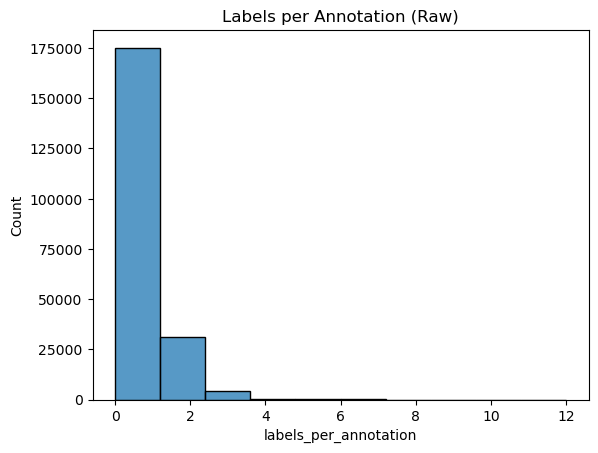

In [12]:
sns.histplot(df["labels_per_annotation"], bins=10)
plt.title("Labels per Annotation (Raw)")
plt.show()

### Number of annotations per comment

In [13]:
raters_per_comment = df.groupby("id")["rater_id"].nunique()

raters_per_comment.describe()

count    58011.000000
mean         3.641120
std          0.935532
min          1.000000
25%          3.000000
50%          3.000000
75%          5.000000
max          5.000000
Name: rater_id, dtype: float64

Most comments receive 3–5 annotations , providing a reasonable basis for measuring annotator disagreement.

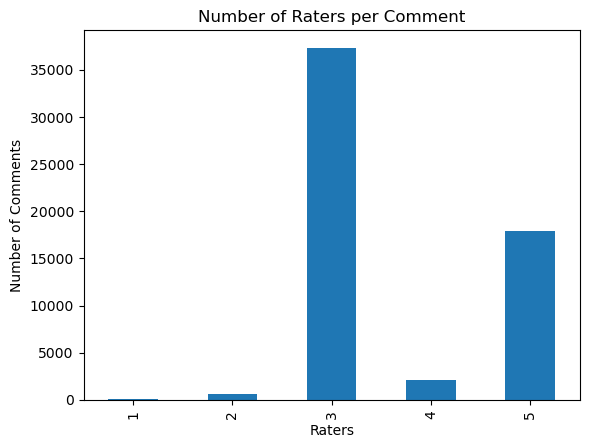

In [14]:
raters_per_comment.value_counts().sort_index().plot(kind="bar")
plt.title("Number of Raters per Comment")
plt.xlabel("Raters")
plt.ylabel("Number of Comments")
plt.show()

### `example_very_unclear`

The example_very_unclear field contains no positive values in this dataset version. Alternative measures of ambiguity are required. 

In [15]:
df["example_very_unclear"].value_counts(dropna=False)

example_very_unclear
False    211225
Name: count, dtype: int64

In [16]:
print("Percent unclear annotations:",
      df["example_very_unclear"].mean() * 100)

Percent unclear annotations: 0.0


### Subreddit Distribution

In [17]:
subreddit_counts = df.groupby("subreddit")["id"].nunique().sort_values(ascending=False)

subreddit_counts.head(15)

subreddit
loveafterlockup          241
cringe                   239
socialanxiety            232
AnimalsBeingBros         231
90dayfianceuncensored    221
vanderpumprules          221
timberwolves             220
confessions              220
TheSimpsons              219
TeenMomOGandTeenMom2     217
90DayFiance              216
danganronpa              214
wholesomememes           214
OkCupid                  214
exmormon                 212
Name: id, dtype: int64

The relatively uniform distribution across top subreddits suggests no single community dominates the dataset, which is beneficial for clustering analysis.

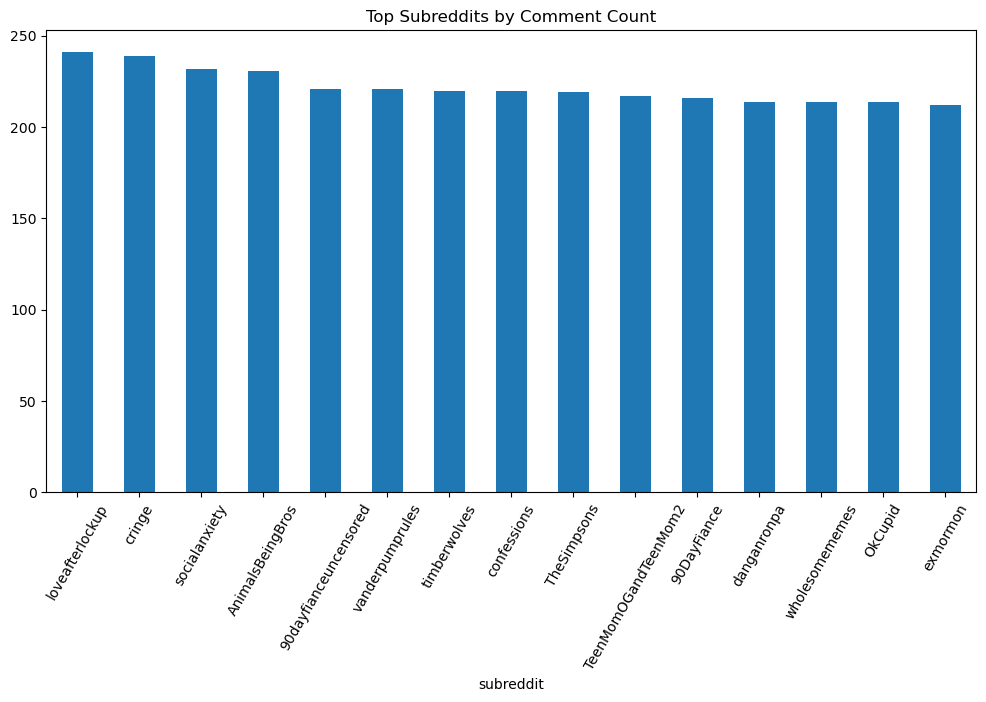

In [18]:
plt.figure(figsize=(12,6))
subreddit_counts.head(15).plot(kind="bar")
plt.title("Top Subreddits by Comment Count")

plt.xticks(rotation=60)
plt.show()